![header](../figures/logos_partenaires._cmems_se.jpg)

# Benchmark DUACS sea surface height maps

<div style="text-align: right"><i> 2023-04-27 DUACS_SSH_BENCHMARK_DEMO </i></div>

***
**Authors:**  CLS & Datlas <br>
**Copyright:** 2023 CLS & Datlas <br>
**License:** MIT

<div class="alert alert-block alert-success">
<h1><center>Benchmark of DUACS sea surface height maps</center></h1>
<h5> The notebook aims to evaluate the sea surface height maps produced by the DUACS system. </h5>
    <h5> These maps are equivalent to the SEALEVEL_GLO_PHY_L4_MY_008_047 product distributed by the Copernicus Marine Service, except that a nadir altimeter (SARAL/Altika, SEALEVEL_GLO_PHY_L3_MY_008_062 product) has been excluded from the mapping. </h5>
        <h5> We provide below a demonstration of the validation of these maps against the independent SSH data from the Saral/AltiKa altimeter distributed by CMEMS </h5>
</div>

***
**General Note 1**: Execute each cell through the <button class="btn btn-default btn-xs"><i class="icon-play fa fa-play"></i></button> button from the top MENU (or keyboard shortcut `Shift` + `Enter`).<br>
<br>
**General Note 2**: If, for any reason, the kernel is not working anymore, in the top MENU, click on the <button class="btn btn-default btn-xs"><i class="fa fa-repeat icon-repeat"></i></button> button. Then, in the top MENU, click on "Cell" and select "Run All Above Selected Cell".<br>
***


<div class="alert alert-danger" role="alert">

<h3>Learning outcomes</h3>

At the end of this notebook you will know:
<ul>
  <li>How you can evaluated sea surface height maps with independent alongtrack data: statistical and spectral analysis</li>
</ul>
    
</div>

In [3]:
#%pip install hvplot

Note: you may need to restart the kernel to use updated packages.


In [6]:
#%pip install --dry-run 'numpy<2' numba

  Using cached numpy-1.24.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
Using cached numpy-1.24.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
Would install numpy-1.24.4
Note: you may need to restart the kernel to use updated packages.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')
from src.mod_plot import *
from src.mod_stat import *
from src.mod_spectral import *
from src.mod_interp import *
from src.mod_intervals import *
from glob import glob
import numpy as np
import os

In [3]:
import logging
logger = logging.getLogger()
logger.setLevel(logging.INFO)

<div class="alert alert-info" role="alert">

<h2>0. Parameters</h2>

</div>

In [4]:
time_min = '2019-01-01'                                        # time min for analysis
time_max = '2019-12-31'                                        # time max for analysis
output_dir = '../results'                                      # output directory path
os.system(f'mkdir -p {output_dir}')
method_name = 'DUACS'
stat_output_filename = f'{output_dir}/stat_sla_duacs_geos.nc'  # output statistical analysis filename
lambda_min = 65.                                               # minimun spatial scale in kilometer to consider on the filtered signal
lambda_max = 500.                                              # maximum spatial scale in kilometer to consider on the filtered signal
psd_output_filename = f'{output_dir}/psd_sla_duacs_geos.nc'    # output spectral analysis filename
segment_lenght = 1000.                                         # spectral parameer: along-track segment lenght in kilometer to consider in the spectral analysis

<div class="alert alert-info" role="alert">

<h2>1. Input files</h2>

</div>

## Sea Surface Height from Saral/AltiKa

In [5]:
#time_min = '2023-01-15'                                        # time min for analysis
#time_max = '2023-12-31'                                        # time max for analysis
#
#list_of_file = sorted(glob('/Odyssey/public/altimetry_traces/processed_2023_global_4/dl/ref/alg/**/*2024*/2023/**/*.nc'))
##sorted(glob('../data/independent_alongtrack/alg/2019/*.nc'))
#ds_alg = xr.open_mfdataset(list_of_file, combine='nested', concat_dim='time')
#ds_alg = ds_alg.where((ds_alg.time >= np.datetime64(time_min)) & (ds_alg.time <=  np.datetime64(time_max)), drop=True)
#ds_alg["longitude"] = (ds_alg["longitude"] % 360).where(ds_alg["longitude"] != 360, 0)
#ds_alg['ssh'] = ds_alg['sla_filtered'] + ds_alg['mdt']
#ds_alg = ds_alg.sortby(['time', 'longitude', 'latitude'])
#ds_alg

In [6]:
time_min = '2023-01-15'                                        # time min for analysis
time_max = '2023-12-31'                                        # time max for analysis

list_of_file = sorted(glob('/Odyssey/public/altimetry_traces/processed_2023_global_4/dl/ref/*/**/*2024*/2023/**/*.nc'))

ds_alg = xr.open_mfdataset(list_of_file)
ds_alg = ds_alg.pipe(
lambda d: d.where(
    (d.time.load() >= pd.to_datetime(time_min))
    & (d.time <= pd.to_datetime(time_max)),
    drop=True,
    )
    ).assign(ssh=lambda d: d.sla_filtered + d.mdt).sortby("time")[["ssh", "sla_filtered", "sla_unfiltered", "mdt", "lwe"]]
ds_alg = ds_alg.where((ds_alg.time >= np.datetime64(time_min)) & (ds_alg.time <=  np.datetime64(time_max)), drop=True)

ds_alg["longitude"] = (ds_alg["longitude"] % 360).where(ds_alg["longitude"] != 360, 0)
ds_alg

<xarray.Dataset> Size: 891MB
Dimensions:         (time: 13925849)
Coordinates:
  * time            (time) datetime64[ns] 111MB 2023-01-15T23:47:29.547174912...
    latitude        (time) float64 111MB -64.98 -64.92 -64.87 ... -41.95 -42.44
    longitude       (time) float64 111MB 110.1 110.1 110.0 ... 283.5 283.5 283.4
Data variables:
    ssh             (time) float64 111MB dask.array<chunksize=(46461,), meta=np.ndarray>
    sla_filtered    (time) float64 111MB dask.array<chunksize=(46461,), meta=np.ndarray>
    sla_unfiltered  (time) float64 111MB dask.array<chunksize=(46461,), meta=np.ndarray>
    mdt             (time) float64 111MB dask.array<chunksize=(46461,), meta=np.ndarray>
    lwe             (time) float64 111MB dask.array<chunksize=(46461,), meta=np.ndarray>
Attributes: (12/44)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Swath
    comment:                         Sea surface height measured by altimeter...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    summary:                         SSALTO/DUACS Delayed-Time Level-3 sea su...
    time_coverage_duration:          P23H11M4.556364S
    time_coverage_end:               2023-01-01T23:27:36Z
    time_coverage_resolution:        P1S
    time_coverage_start:             2023-01-01T00:16:31Z
    title:                           DT Altika Drifting Phase Global Ocean Al...

In [7]:
m_var, s_var = ds_alg.sla_filtered.pipe(lambda da: (da.mean().values.item(), da.std().values.item()))
m_var, s_var

(0.09858510144176538, 0.09872823753059462)

## Sea Surface Height maps to evaluate

In [8]:
glo12_paths = '/Odyssey/public/glorys/mercator_forecast/glo12/R202*/'
#ds_maps = get_preprocessed_rec_mercator_forecast(glo12_paths, leadtime_index=0)
ds_maps = xr.open_dataset('/Odyssey/public/glorys/rec/glorys4_global_movpatch_softedge_fastrec_GPU_1patch/nrt_2023_global_4/test_data_14.nc')

# select wednesdays
ds_maps = ds_maps.sel(time=ds_maps.time.dt.weekday == 2)
ds_maps["time"] = ds_maps["time"] + pd.to_timedelta(12, unit="h")

ds_maps = ds_maps.sel(time=slice(time_min, time_max)).rename({'out':'ssh', 'lat':'latitude', 'lon':'longitude'})
ds_maps

<xarray.Dataset> Size: 133MB
Dimensions:    (time: 34, latitude: 680, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 272B 2023-01-18T12:00:00 ... 2023-09-06T...
  * latitude   (latitude) float64 5kB -80.0 -79.75 -79.5 ... 89.25 89.5 89.75
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    ssh        (time, latitude, longitude) float32 133MB ...

In [9]:
m_var, s_var = ds_maps.ssh.pipe(lambda da: (da.mean().values.item(), da.std().values.item()))
m_var, s_var

(0.059625864028930664, 0.6984235644340515)

## Time restriction for methods with Intervals between leadtimes

In [21]:
# RESTRICT TIME TO 0.5 DAYS AROUND RECONSTRUCTED LEADTIMES
ds_alg = ds_alg.sel(time=restrict_time_alongtrack(ds_alg.time.values, ds_maps.time.values, days_offset=5))
ds_alg = ds_alg.sortby(['time', 'longitude', 'latitude'])
ds_alg

<xarray.Dataset> Size: 88MB
Dimensions:         (time: 1379320)
Coordinates:
  * time            (time) datetime64[ns] 11MB 2023-01-17T23:58:57.210592768 ...
    latitude        (time) float64 11MB -18.9 -18.96 -19.03 ... 28.43 25.43
    longitude       (time) float64 11MB 265.7 265.7 265.7 ... 296.1 296.1 295.3
Data variables:
    ssh             (time) float64 11MB dask.array<chunksize=(45328,), meta=np.ndarray>
    sla_filtered    (time) float64 11MB dask.array<chunksize=(45328,), meta=np.ndarray>
    sla_unfiltered  (time) float64 11MB dask.array<chunksize=(45328,), meta=np.ndarray>
    mdt             (time) float64 11MB dask.array<chunksize=(45328,), meta=np.ndarray>
    lwe             (time) float64 11MB dask.array<chunksize=(45328,), meta=np.ndarray>
Attributes: (12/44)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Swath
    comment:                         Sea surface height measured by altimeter...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    summary:                         SSALTO/DUACS Delayed-Time Level-3 sea su...
    time_coverage_duration:          P23H11M4.556364S
    time_coverage_end:               2023-01-01T23:27:36Z
    time_coverage_resolution:        P1S
    time_coverage_start:             2023-01-01T00:16:31Z
    title:                           DT Altika Drifting Phase Global Ocean Al...

## Very important manipulation in order to make DC21 notebooks work ! 

In [22]:
ds_maps["longitude"] = (ds_maps["longitude"] % 360).where(ds_maps["longitude"] != 360, 0)
lon_unique, index = np.unique(ds_maps.coords["longitude"], return_index=True)
ds_maps = ds_maps.isel(longitude=index)
ds_maps.latitude.attrs['units'] = 'degrees_north'
ds_maps.longitude.attrs['units'] = 'degrees_east'
ds_maps = ds_maps.sortby(['time', 'longitude', 'latitude'])
ds_maps

<xarray.Dataset> Size: 133MB
Dimensions:    (time: 34, latitude: 680, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 272B 2023-01-18T12:00:00 ... 2023-09-06T...
  * latitude   (latitude) float64 5kB -80.0 -79.75 -79.5 ... 89.25 89.5 89.75
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    ssh        (time, latitude, longitude) float32 133MB -1.182 -1.182 ... nan

## SLA becomes SSH in our version of evaluation workflow: add MDT as variable to the ds_maps dataset

In [23]:
#mdt_ds = xr.open_dataset("/Odyssey/public/duacs/1993_2013/duacs_global_0.25deg_1993_2013_mdt.nc")
#mdt_3d = np.repeat(mdt_ds.mdt.values[np.newaxis, :, :], 337, axis=0) # 337 days with 15 days missing in the beginning of the year (confirm Pierre)
#ds_maps['mdt'] = (['time', 'latitude', 'longitude'], mdt_3d[:,:]) # 40: only for 4dvarnet

mdt_maps = xr.open_dataset("/Odyssey/public/duacs/1993_2013/duacs_global_0.25deg_1993_2013_mdt.nc").expand_dims({'time': ds_maps.time.values}, axis=0)
mdt_maps["longitude"] = (mdt_maps["longitude"] % 360).where(mdt_maps["longitude"] != 360, 0)
mdt_maps.latitude.attrs['units'] = 'degrees_north'
mdt_maps.longitude.attrs['units'] = 'degrees_east'
mdt_maps = mdt_maps.sortby(['time', 'longitude', 'latitude'])
#.broadcast_like(ds_maps)
#mdt_array = xr.DataArray(
#    data=mdt_map,
#    coords=dict(
#        latitude=ds_maps.latitude.values,
#        longitude=ds_maps.longitude.values,
#    )
#)
#ds_maps['ssh'] = ds_maps['out'] + mdt_map
mdt_maps


<xarray.Dataset> Size: 282MB
Dimensions:    (time: 34, latitude: 720, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 272B 2023-01-18T12:00:00 ... 2023-09-06T...
  * latitude   (latitude) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * longitude  (longitude) float64 12kB 0.125 0.375 0.625 ... 359.4 359.6 359.9
Data variables:
    mdt        (time, latitude, longitude) float64 282MB nan nan nan ... nan nan

<div class="alert alert-info" role="alert">

<h2>2. Statistical & Spectral Analysis </h2>

</div>

## 2.1 Interpolate sea surface height maps onto along-track positions

### 2.1.1 Additionally, interpolate mdt from ds_maps onto along-track positions -> changed /src/mod_interp.py

In [24]:
ds_interp = run_interpolation_ssh(ds_maps, ds_alg, var_alongtrack='ssh', var_rec='ssh', forecast_interval=True)
#ds_interp = ds_interp.drop_vars('tpa_correction').dropna('time')
ds_interp_mdt = run_interpolation_ssh(mdt_maps, ds_alg, var_alongtrack='ssh', var_rec='mdt', forecast_interval=True)
#ds_interp_mdt = ds_interp_mdt.drop_vars('tpa_correction').dropna('time')

2025-01-24 16:45:36 INFO     fetch data from 2023-01-18 12:00:00 to 2023-02-01 12:00:00
2025-01-24 16:45:36 INFO     fetch data from 2023-01-25 12:00:00 to 2023-03-01 12:00:00
2025-01-24 16:45:36 INFO     fetch data from 2023-02-22 12:00:00 to 2023-04-05 12:00:00
2025-01-24 16:45:36 INFO     fetch data from 2023-03-29 12:00:00 to 2023-05-03 12:00:00
2025-01-24 16:45:36 INFO     fetch data from 2023-04-26 12:00:00 to 2023-06-07 12:00:00
2025-01-24 16:45:37 INFO     fetch data from 2023-05-31 12:00:00 to 2023-07-05 12:00:00
2025-01-24 16:45:37 INFO     fetch data from 2023-06-28 12:00:00 to 2023-08-02 12:00:00
2025-01-24 16:45:37 INFO     fetch data from 2023-07-26 12:00:00 to 2023-09-06 12:00:00
2025-01-24 16:45:37 INFO     fetch data from 2023-08-30 12:00:00 to 2023-09-06 12:00:00
2025-01-24 16:45:38 INFO     fetch data from 2023-01-18 12:00:00 to 2023-02-01 12:00:00
2025-01-24 16:45:38 INFO     fetch data from 2023-01-25 12:00:00 to 2023-03-01 12:00:00
2025-01-24 16:45:38 INFO     fet

In [25]:
from matplotlib import pyplot as plt

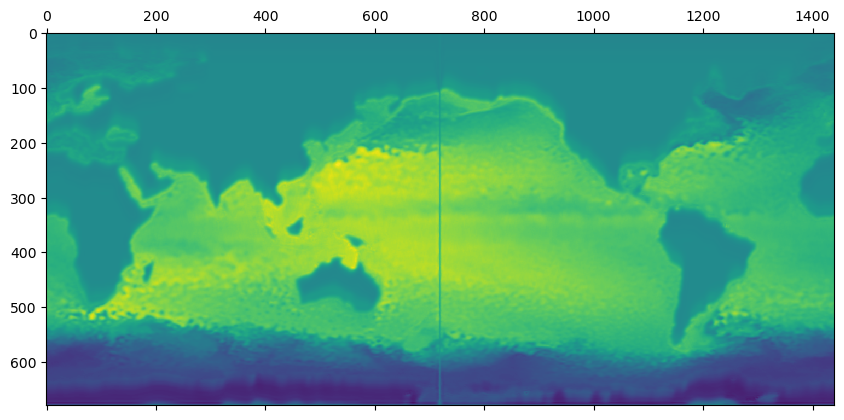

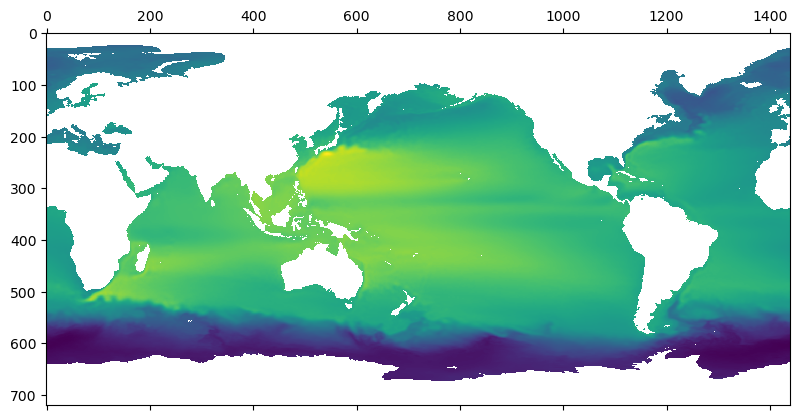

In [15]:
plt.matshow(ds_maps.ssh.values[0,::-1])
plt.matshow(mdt_maps.mdt.values[0,::-1])

### 2.1.2 Now replace SLA from altimeters to SSH: SSH_altimeters = SLA_altimeters + MDT_interpolated

In [16]:
ds_interp['sla_unfiltered'] = ds_interp['sla_unfiltered'] + ds_interp_mdt['mssh_interpolated']
ds_interp['sla_filtered'] = ds_interp['sla_filtered'] + ds_interp_mdt['mssh_interpolated']
ds_interp['msla_interpolated'] = ds_interp['mssh_interpolated']

ValueError: These variables cannot be found in this dataset: ['tpa_correction']

In [17]:
ds_interp = ds_interp.dropna('time')


In [18]:
m_var, s_var = ds_interp.sla_unfiltered.pipe(lambda da: (da.mean().values.item(), da.std().values.item()))
m_var, s_var

(0.4176761625891812, 0.6921109298860414)

In [19]:
m_var, s_var = ds_interp.msla_interpolated.pipe(lambda da: (da.mean().values.item(), da.std().values.item()))
m_var, s_var

(0.38828762961041907, 0.6717810307904977)

2025-01-24 14:12:51 INFO     Compute mapping error all scales
2025-01-24 14:12:51 INFO     Compute mapping error for scales between 65.0 and 500.0 km
Total RMSE= 0.073872999293539 m
Total RMSE score= 0.9087194550609237 m
2025-01-24 14:13:01 INFO     Compute binning statistics
2025-01-24 14:13:03 INFO     Compute statistics by oceanic regime


## 2.2 Compute grid boxes statistics & statistics by regime (coastal, offshore low variability, offshore high variability)

Once the maps have been interpolated to the position of the along-track, it is possible to calculate different statistics on the time series SLA_alongtrack and SLA_maps. 

We propose below the following statistics: error variance maps (static by 1°x1° box), explained variance maps, temporal evolution of global error variance and explained variance. 

These statistics are also applied to the filtered signals focusing on the 65-500km scale range. A bandpass filter is applied before calculating the scores.  

In [20]:
compute_stat_scores(ds_interp, lambda_min, lambda_max, stat_output_filename, method_name, freq_out='1D', land_sea_mask='/Odyssey/public/data_challenge_ssh_ose/data/sad/land_water_mask_60.nc', variance_ssh='/Odyssey/public/data_challenge_ssh_ose/data/sad/variance_cmems_dt_allsat.nc', distance_to_nearest_coast='/Odyssey/public/data_challenge_ssh_ose/data/sad/distance_to_nearest_coastline_60.nc')

2025-01-24 16:44:04 INFO     Compute mapping error all scales


2025-01-24 16:44:04 INFO     Compute mapping error for scales between 65.0 and 500.0 km


Total RMSE= 0.07381456684796894 m
Total RMSE score= 0.9087910660657535 m


2025-01-24 16:44:14 INFO     Compute binning statistics
2025-01-24 16:44:18 INFO     Compute statistics by oceanic regime
2025-01-24 16:44:39 INFO     Stat file saved as: ../results/stat_sla_duacs_geos.nc


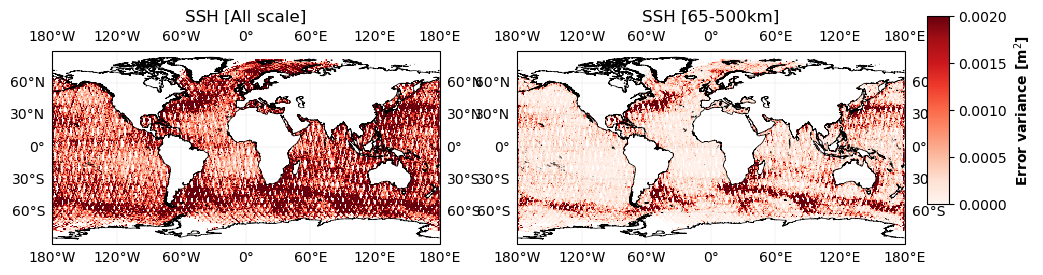

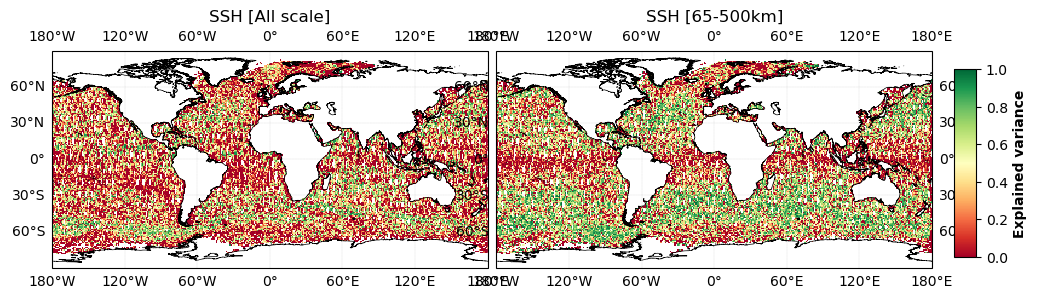

In [14]:
# Plot gridded stats
# Hvplot
# plot_stat_score_map(stat_output_filename)
# Matplotlib
plot_stat_score_map_png(stat_output_filename)

In [15]:
plot_stat_score_timeseries(stat_output_filename)

:Layout
   .Overlay.I  :Overlay
      .Curve.All_scale :Curve   [time]   (timeserie_variance_mapping_err)
      .Curve.Filtered  :Curve   [time]   (timeserie_variance_mapping_err)
   .Overlay.II :Overlay
      .Curve.All_scale :Curve   [time]   (explained_variance_score)
      .Curve.Filtered  :Curve   [time]   (explained_variance_score)

### 2.2.1 I modified /src/mod_stat.py in order to add the computation of nRMSE score for mappieng err; I also modified /src/mod_plot.py in order to include RMSE and nRMSE score to the table

In [16]:
plot_stat_by_regimes(stat_output_filename)

,mapping_err_var [m²],mapping_err_rms,mapping_err_nrms_score,sla_unfiltered_var [m²],sla_unfiltered_rms,sla_unfiltered_nrms_score,mapping_err_filtered_var [m²],mapping_err_filtered_rms,mapping_err_filtered_nrms_score,sla_filtered_var [m²],sla_filtered_rms,sla_filtered_nrms_score,var_score_allscale,var_score_filtered
coastal,0.004944,0.078884,0.902528,0.354613,0.833419,0.902528,0.000969,0.031131,0.902528,0.002530,0.050300,0.902528,0.986058,0.616993
offshore_highvar,0.018227,0.140409,0.826505,0.336116,0.774418,0.826505,0.006745,0.082142,0.826505,0.026032,0.162081,0.826505,0.945772,0.740875
offshore_lowvar,0.003268,0.063973,0.920952,0.515905,0.803230,0.920952,0.000678,0.026035,0.920952,0.002282,0.047800,0.920952,0.993666,0.703030
equatorial_band,0.003110,0.070305,0.913128,0.057913,0.879461,0.913128,0.000424,0.020593,0.913128,0.000606,0.024645,0.913128,0.946290,0.300068
arctic,0.002735,0.052949,0.934574,0.013786,0.275918,0.934574,0.000543,0.023296,0.934574,0.000890,0.029845,0.934574,0.801642,0.390452
antarctic,0.006334,0.081192,0.899675,0.004295,1.202025,0.899675,0.001980,0.044490,0.899675,0.000772,0.027804,0.899675,-0.474816,-1.564348


## 2.3 Compute Spectral scores

In [ ]:
compute_psd_scores_v2(ds_interp, psd_output_filename, lenght_scale=segment_lenght,method_name=method_name)

2024-09-11 20:21:28 INFO     Segment computation...
2024-09-11 20:21:40 INFO     Spectral analysis...
2024-09-11 20:36:31 INFO     Saving ouput...
2024-09-11 20:36:40 INFO     PSD file saved as: ../results/psd_sla_duacs_geos.nc


Averaged effective resolution: 218.18302355039634 km


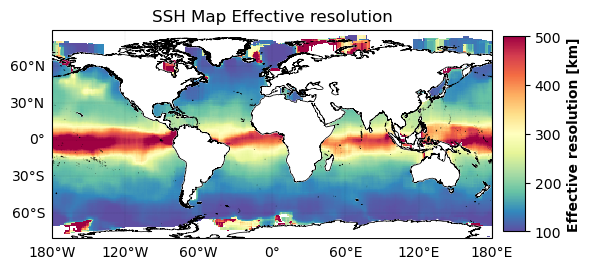

In [ ]:
# Plot effective resolution
# Hvplot
# plot_effective_resolution(psd_output_filename)
# Matplotlib
plot_effective_resolution_png(psd_output_filename)

In [ ]:
plot_psd_scores(psd_output_filename)

:Layout
   .DynamicMap.I   :DynamicMap   [lon,lat]
      :Overlay
         .Curve.PSD_alongtrack   :Curve   [wavelenght]   (psd_ref)
         .Curve.NOISE_alongtrack :Curve   [wavelenght]   (noise)
         .Curve.PSD_map          :Curve   [wavelenght]   (psd_study)
         .Curve.PSD_err          :Curve   [wavelenght]   (psd_diff)
   .DynamicMap.II  :DynamicMap   [lon,lat]
      :Overlay
         .Curve.PSD_map_over_PSD_ref :Curve   [wavelenght]   (psd_ratio)
         .Curve.I                    :Curve   [wavelenght]   (coherence)
   .DynamicMap.III :DynamicMap   [lon,lat]
      :Overlay
         .Curve.I  :Curve   [wavelenght]   (psd_score)
         .Curve.II :Curve   [wavelenght]   (coherence)
   .DynamicMap.IV  :DynamicMap   [lon,lat]
      :Overlay
         .Curve.I  :Curve   [wavelenght]   (coherence)
         .Curve.II :Curve   [wavelenght]   (coherence)

The interactive plot above allows you to explore the spectral metrics by latitude / longitude box